In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import healpy as hp
import fitsio
from astropy.table import Table
import scienceplots
plt.style.use(['science','notebook','grid'])
from astropy.table import Table
import fitsio
import pyccl as ccl
from scipy.optimize import curve_fit as cf


nside=1024
npix= 12*nside**2

In [2]:
def get_mask(ra,dec,nside):
    theta = np.radians(90 -dec)
    phi = np.radians(ra)
    pix = hp.ang2pix(nside, theta, phi)
    mask = np.bincount(pix, minlength=hp.nside2npix(nside))
    mask = np.where(mask>0, 1, 0)
    return mask
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m
def plot_map(map,nside=1024):
    hp.mollview(map, title="Map", cmap='Blues', norm='hist', cbar=False)
    hp.graticule()
    plt.show()

In [3]:
table_selection = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/table_match_final.fits')[1].read())
RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
RA_data   = np.ascontiguousarray(np.array(RA_data, dtype=np.float64))
DEC_data  = np.ascontiguousarray(np.array(DEC_data, dtype=np.float64))

In [4]:
north = Table(fitsio.FITS('../../FP_CUTS/table_north_unique.fits')[1].read())
south  = Table(fitsio.FITS('../../FP_CUTS/table_south_unique.fits')[1].read())
ra_north,dec_north = north['RA'], north['DEC']  
ra_south,dec_south = south['RA'], south['DEC']  




In [5]:
##making a mask



# random_compiled = fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_1.fits')[1].read()
# rand_table=Table(random_compiled)
# rand_table = rand_table[rand_table['DEC'] > -30]
# RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
# RA_random,DEC_random = rand_table['RA'], rand_table['DEC']  
# RA_random = np.ascontiguousarray(np.array(RA_random, dtype=np.float64))
# DEC_random= np.ascontiguousarray(np.array(DEC_random, dtype=np.float64))
# rand_map = points_to_map(RA_random, DEC_random, nside, None)


In [6]:
data_map = points_to_map(RA_data, DEC_data, nside, None)
mask=np.load('../cl_estimate_backup/mask_dense.npy')

#mask = np.load('/user/animesh.sah/DESI_PECVEL/mask_full.npy')
data_north = points_to_map(ra_north, dec_north, nside, None)
data_south = points_to_map(ra_south, dec_south, nside,
    None)   

mask_north = np.load('/user/animesh.sah/DESI_PECVEL/mask_north.npy')
mask_south = np.load('/user/animesh.sah/DESI_PECVEL/mask_south.npy')

In [7]:
def get_cl(data_map,mask,nside=1024,lmax=1000):
    npix= 12*nside**2
    tot1=np.sum(mask)
    tot2=np.sum(data_map)
    fsky=tot1/npix
    rntot1=np.copy(tot2)
    ll=np.arange(0,lmax+1)
    map1=mask*(data_map*tot1/tot2 - 1)
    a1=hp.map2alm(map1,lmax=lmax)
    p1=hp.alm2cl(a1)
    dl1=ll*(ll+1)/2/np.pi*p1/fsky
    pshot=2*fsky*ll*(1+ll)/rntot1
    dl1 = dl1 - pshot
    return dl1,pshot,fsky,rntot1

def bin_cl(dl1,pshot1,fsky,rntot1,nell=10,lmax=1000):
    bins = np.arange(nell, lmax+nell, nell)
    bin_centers= (bins[1:]+bins[:-1])/2
    #bin_centers = np.r_[bins[0]/2,bin_centers]
    breakpoints=np.arange(nell,len(dl1)-1,nell)+1
    #starts = np.r_[0,breakpoints]
    sums = np.add.reduceat(dl1, breakpoints)
    sumsq = np.add.reduceat(dl1**2, breakpoints)
    pshot1 = 2*fsky*bin_centers * (1+bin_centers)/rntot1 
    dCl = np.sqrt(sumsq/nell  - (sums**2)/nell**2)/(np.sqrt(fsky))/np.sqrt(nell-1)
    Cl = sums/nell # - pshot1
    return bin_centers,Cl,dCl

# plt.plot(dl1,'.')
# dl1=dl1-pshot
# plt.plot(dl1,'.')


In [8]:
# d1 is an array of CL values for l values from 0 to lmax
# Now we will bin these CL values in bins of size nell=10

In [9]:
bin_centers,Cl,dCl = bin_cl(*get_cl(data_map,mask),nell=10)
bin_north, Cl_north, dCl_north = bin_cl(*get_cl(data_north,mask_north),nell=10) 
bin_south, Cl_south, dCl_south = bin_cl(*get_cl(data_south,mask_south),nell=10)


Text(0.5, 1.0, 'Angular Power Spectrum')

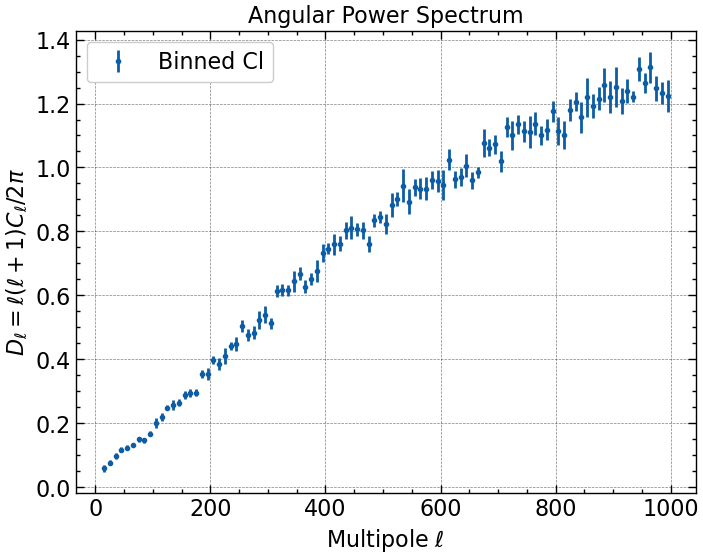

In [10]:
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
#plt.yscale('log')
plt.legend()
plt.title('Angular Power Spectrum')

Text(0.5, 1.0, 'Angular Power Spectrum')

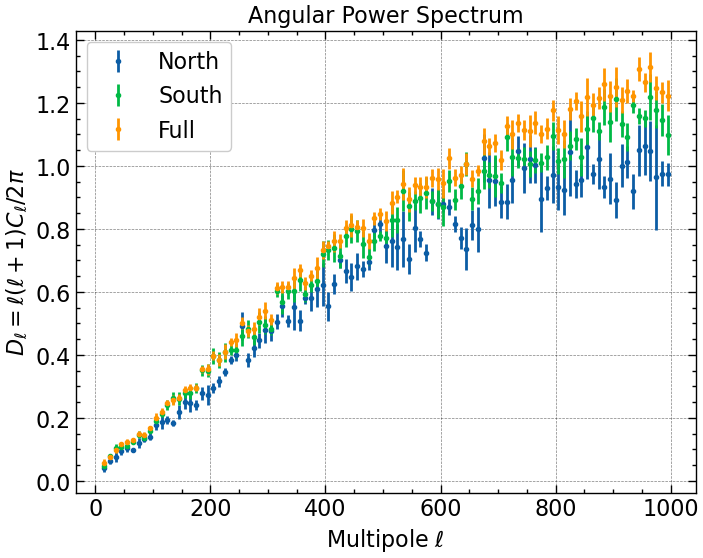

In [11]:
plt.errorbar(bin_north,Cl_north,yerr=dCl_north,fmt='.',label='North')
plt.errorbar(bin_south,Cl_south,yerr=dCl_south,fmt='.',label='South')
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Full')

plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/  2\pi$')
#plt.yscale('log')
plt.legend()
plt.title('Angular Power Spectrum')

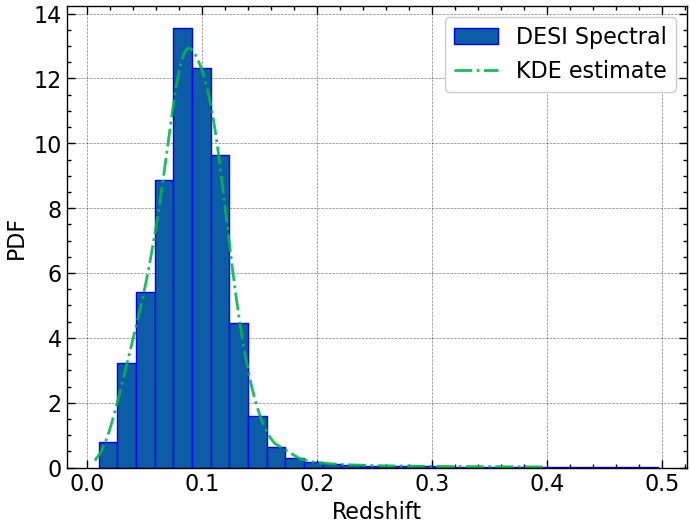

In [12]:
from scipy.stats import gaussian_kde
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(500).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

plt.plot(samples_sorted,y_samples_sorted,'-.',alpha=0.9,label='KDE estimate')
plt.xlabel('Redshift')
plt.ylabel('PDF')
plt.legend()
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)


In [112]:
cosmo = ccl.Cosmology(
    Omega_c=0.25,  # Cold dark matter density
    Omega_b=0.05,  # Baryon density
    h=0.67,        # Hubble parameter
    sigma8=0.8,    # Power spectrum normalization
    n_s=0.96       # Spectral index
)

cosmo_hmcode = ccl.Cosmology(
    Omega_c=0.25,  # Cold dark matter density
    Omega_b=0.05,  # Baryon density
    h=0.67,        # Hubble parameter
    sigma8=0.8,    # Power spectrum normalization
    n_s=0.96       # Spectral index,
    ,matter_power_spectrum="camb",
    
    extra_parameters={
        "camb": {
            "halofit_version": "halomodel",
            "HMCode_A_baryon": 3.13,
            "HMCode_eta_baryon": 0.603,
            "HMCode_logT_AGN": 7.8
        }
    }

)


z=samples_sorted
n_z = y_samples_sorted
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell = np.arange(0, 200)

def dll(ell,a):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return a*dl 

def dll_hm(ell,a):
    gal_tracer_2 = ccl.NumberCountsTracer(cosmo_hmcode, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
    cls_gg = ccl.angular_cl(cosmo_hmcode, gal_tracer_2, gal_tracer_2, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return a*dl

In [111]:
popt1

array([2.53418672])

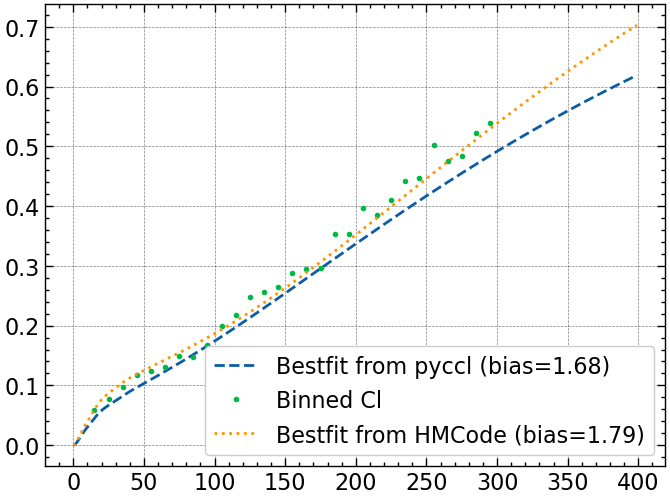

In [120]:
ell = np.arange(0, 400)
#plt.plot(bin_centers[bin_centers<300],dll(1.6,bin_centers[bin_centers<300]),label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
plt.plot(ell,dll(ell,2.55),'--',label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
plt.plot(bin_centers[bin_centers<300],Cl[bin_centers<300],label='Binned Cl',marker= '.',ls='None')
popt1,pcov1=cf(dll_hm,bin_centers[bin_centers<200],Cl[bin_centers<200],sigma=dCl[bin_centers<200],p0=[3])
plt.plot(ell,dll_hm(ell,popt1),':',label='Bestfit from HMCode (bias={:.2f})'.format(np.sqrt(popt1[0])))
plt.legend()

In [71]:
popt_hm

array([2.52404551])

In [117]:
1.81**2

3.2761

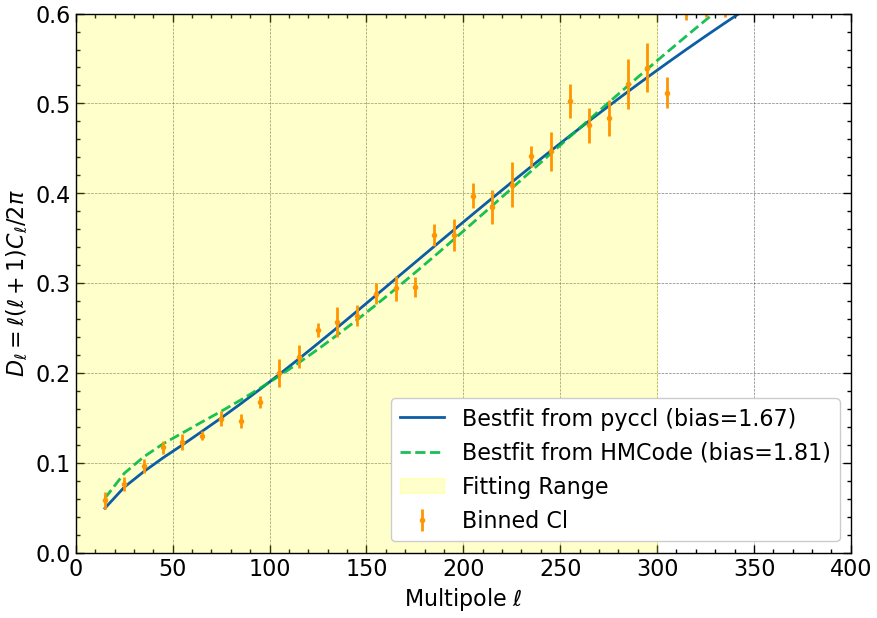

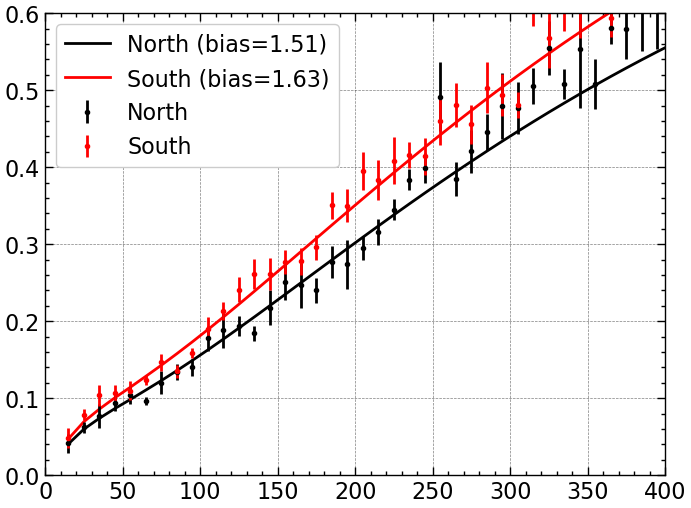

In [116]:
plt.figure(figsize=(10,7))
popt,pcov=cf(dll,bin_centers[bin_centers<300],Cl[bin_centers<300],sigma=dCl[bin_centers<300],p0=[2.25])
popt_hm,pcov_hm=cf(dll_hm,bin_centers[bin_centers<300],Cl[bin_centers<300],sigma=dCl[bin_centers<300],p0=[2.25])

plt.plot(bin_centers,dll(bin_centers,popt),label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
plt.plot(bin_centers,dll_hm(bin_centers,popt_hm),label='Bestfit from HMCode (bias={:.2f})'.format(np.sqrt(popt_hm[0])),ls='--',alpha=0.9)
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlim(0,400)
plt.ylim(0,0.6)
plt.axvspan(0,300,alpha=0.2,color='yellow',label='Fitting Range')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.legend()
plt.show()
poptn,pcovn = cf(dll,bin_north[bin_north<300],Cl_north[bin_north<300],sigma=dCl_north[bin_north<300],p0=[2])
popts,pcovs = cf(dll,bin_south[bin_south<300],Cl_south[bin_south<300],sigma=dCl_south[bin_south<300],p0=[2])
plt.plot(bin_north,dll(bin_north,poptn),label='North (bias={:.2f})'.format(np.sqrt(poptn[0])),color='k')
plt.plot(bin_south,dll(bin_south,popts),label='South (bias={:.2f})'.format(np.sqrt(popts[0])),color='r')
plt.errorbar(bin_north,Cl_north,yerr=dCl_north,fmt='.',label='North',color='k')
plt.errorbar(bin_south,Cl_south,yerr=dCl_south,fmt='.',label='South',color='r')
plt.xlim(0,400)         
plt.ylim(0,0.6)

plt.legend()



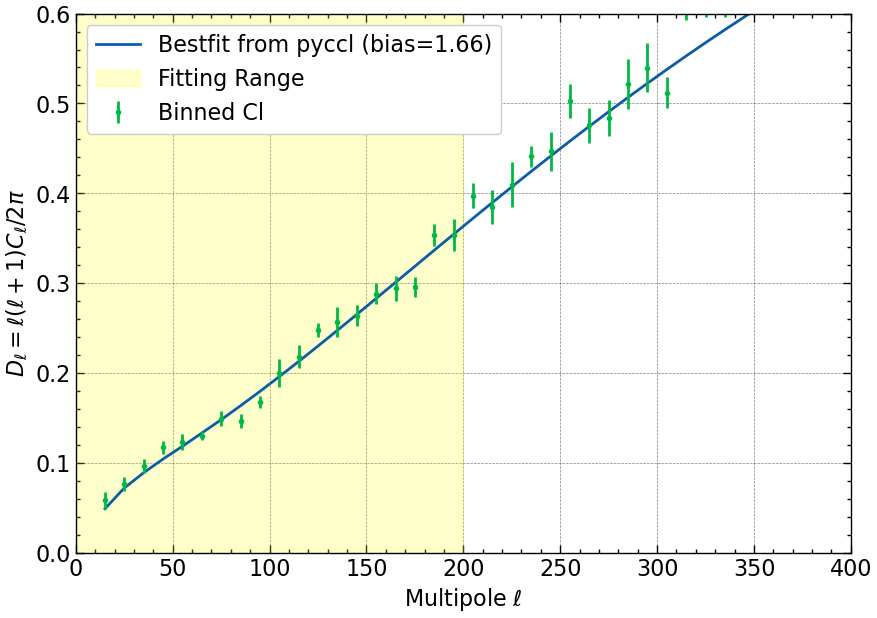

In [118]:
plt.figure(figsize=(10,7))

popt,pcov=cf(dll,bin_centers[bin_centers<200],Cl[bin_centers<200],sigma=dCl[bin_centers<200],p0=[2])


plt.plot(bin_centers,dll(bin_centers,popt),label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlim(0,400)
plt.ylim(0,0.6)
plt.axvspan(0,200,alpha=0.2,color='yellow',label='Fitting Range')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.legend()

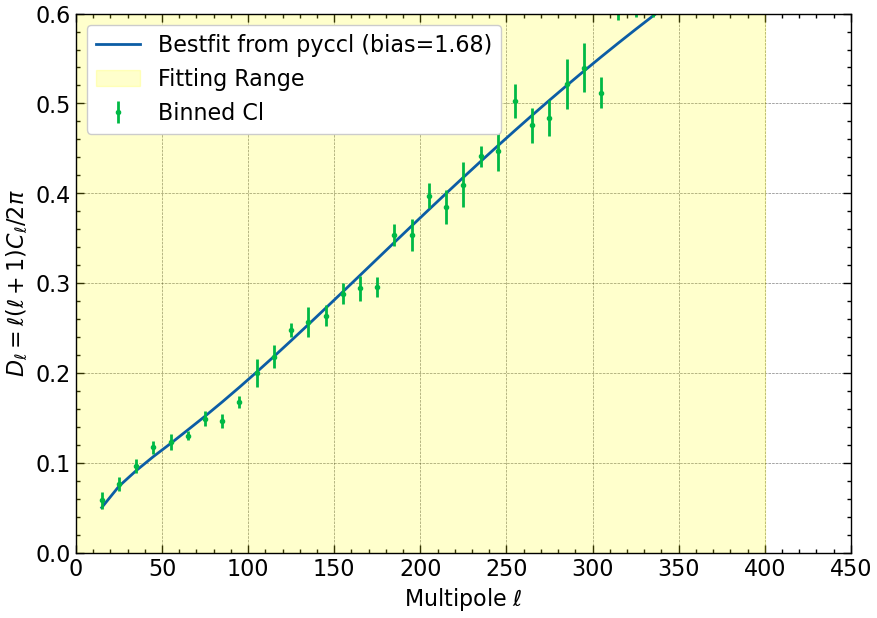

In [119]:
plt.figure(figsize=(10,7))

popt,pcov=cf(dll,bin_centers[bin_centers<400],Cl[bin_centers<400],sigma=dCl[bin_centers<400],p0=[2])


plt.plot(bin_centers,dll(bin_centers,popt),label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlim(0,450)
plt.ylim(0,0.6)
plt.axvspan(0,400,alpha=0.2,color='yellow',label='Fitting Range')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.legend()

In [17]:
north_0_04

NameError: name 'north_0_04' is not defined

In [121]:
north_0_04 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.04.fits')[1].read())
ra_north,dec_north = north_0_04['RA'], north_0_04['DEC']  
data_0_04 = points_to_map(ra_north, dec_north, nside, None)
north_0_01 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.01.fits')[1].read())
ra_north,dec_north = north_0_01['RA'], north_0_01['DEC']  
data_0_01 = points_to_map(ra_north, dec_north, nside, None)
north_0_0234 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.0234.fits')[1].read())
ra_north,dec_north = north_0_0234['RA'], north_0_0234['DEC']  
data_0_0234 = points_to_map(ra_north, dec_north, nside, None)
north_0_03 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.03.fits')[1].read())
ra_north,dec_north = north_0_03['RA'], north_0_03['DEC']  
data_0_03 = points_to_map(ra_north, dec_north, nside, None)
north_min_0_04 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_-0.04.fits')[1].read())
ra_north,dec_north = north_min_0_04['RA'], north_min_0_04['DEC']
data_min_0_04 = points_to_map(ra_north, dec_north, nside, None)



In [122]:
bin_north, Cl_0_04, dCl_0_04 = bin_cl(*get_cl(data_0_04, mask_north), nell=10)
bin_north, Cl_0_01, dCl_0_01 = bin_cl(*get_cl(data_0_01, mask_north), nell=10)
bin_north, Cl_0_0234, dCl_0_0234 = bin_cl(*get_cl(data_0_0234, mask_north), nell=10)    
bin_north, Cl_0_03, dCl_0_03 = bin_cl(*get_cl(data_0_03, mask_north), nell=10)
bin_north, Cl_min_0_04, dCl_min_0_04 =      bin_cl(*get_cl(data_min_0_04, mask_north), nell=10)


Text(0.5, 1.0, 'Angular Power Spectrum')

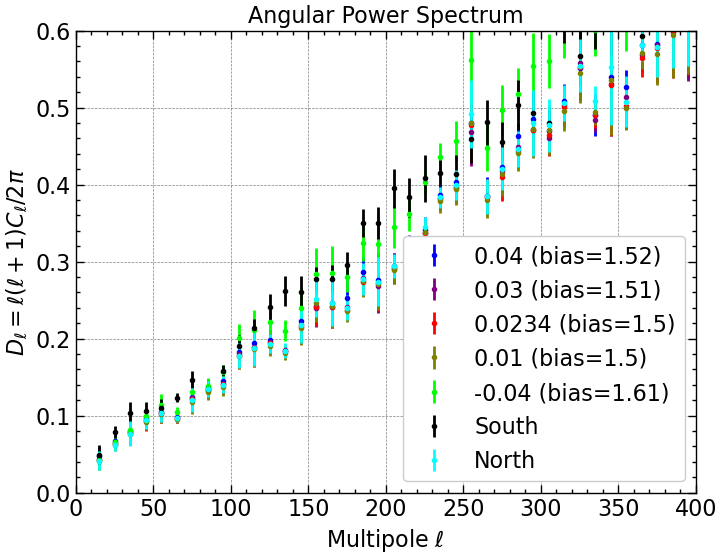

In [123]:
colors = plt.cm.brg(np.linspace(0, 1, 5))
popt_0_04,pcov_0_04=cf(dll,bin_north[bin_north<300],Cl_0_04[bin_north<300],sigma=dCl_0_04[bin_north<300],p0=[2])
popt_0_03,pcov_0_03=cf(dll,bin_north[bin_north<300],Cl_0_03[bin_north<300],sigma=dCl_0_03[bin_north<300],p0=[2])
popt_0_0234,pcov_0_0234=cf(dll,bin_north[bin_north<300],Cl_0_0234[bin_north<300],sigma=dCl_0_0234[bin_north<300],p0=[2])
popt_0_01,pcov_0_01=cf(dll,bin_north[bin_north<300],Cl_0_01[bin_north<300],sigma=dCl_0_01[bin_north<300],p0=[2])
popt_min_0_04,pcov_min_0_04=cf(dll,bin_north[bin_north<300],Cl_min_0_04[bin_north<300],sigma=dCl_min_0_04[bin_north<300],p0=[2])

plt.errorbar(bin_north,Cl_0_04,yerr=dCl_0_04,fmt='.',label=f'0.04 (bias={round(np.sqrt(popt_0_04[0]),2)})',color=colors[0])
plt.errorbar(bin_north,Cl_0_03,yerr=dCl_0_03,fmt='.',label=f'0.03 (bias={round(np.sqrt(popt_0_03[0]),2)})',color=colors[1])
plt.errorbar(bin_north,Cl_0_0234,yerr=dCl_0_0234,fmt='.',label=f'0.0234 (bias={round(np.sqrt(popt_0_0234[0]),2)})',color=colors[2])
plt.errorbar(bin_north,Cl_0_01,yerr=dCl_0_01,fmt='.',label=f'0.01 (bias={round(np.sqrt(popt_0_01[0]),2)})',color=colors[3])
plt.errorbar(bin_north,Cl_min_0_04,yerr=dCl_min_0_04,fmt='.',label=f'-0.04 (bias={round(np.sqrt(popt_min_0_04[0]),2)})',color=colors[4])
plt.errorbar(bin_south,Cl_south,yerr=dCl_south,fmt='.',label='South',color='k')
plt.errorbar(bin_north,Cl_north,yerr=dCl_north,fmt='.',label='North',color='cyan')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/  2\pi$')
#plt.yscale('log')
plt.legend()
plt.xlim(0,400)         
plt.ylim(0,0.6)
plt.title('Angular Power Spectrum') 

In [124]:
popt_0_04, popt_0_03, popt_0_0234, popt_0_01,poptn, popt_min_0_04

(array([2.32201134]),
 array([2.27608196]),
 array([2.26194359]),
 array([2.24304626]),
 array([2.28349532]),
 array([2.6062197]))

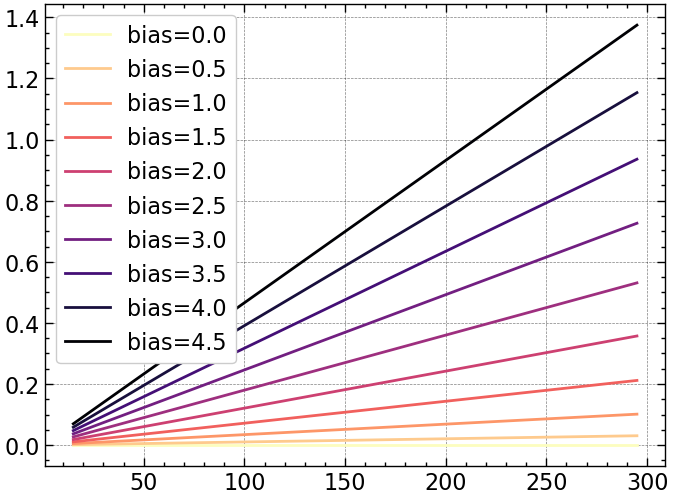

In [125]:
colors = plt.cm.magma_r(np.linspace(0, 1, 10))

for i in range(10):
    plt.plot(bin_north[bin_north<300],dll(i*0.5,bin_north[bin_north<300] ), color=colors[i],label=f'bias={i*0.5}')
plt.legend()